启动FER2013情绪识别模型训练...
Python版本: 3.8.18 (default, Sep 11 2023, 13:40:15) 
[GCC 11.2.0]
TensorFlow版本: 2.10.1
使用训练集路径: ../RAF-DB/train
使用验证集路径: ../RAF-DB/test
Found 12271 images belonging to 7 classes.
Found 3068 images belonging to 7 classes.
已切换到标准数据生成器。
情绪类别: ['anger', 'disgust', 'fear', 'happy', 'normal', 'sad', 'surprised']
Model: "FER_Transformer"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input (InputLayer)             [(None, 96, 96, 1)]  0           []                               
                                                                                                  
 patch_embedding (Conv2D)       (None, 12, 12, 128)  8320        ['input[0][0]']                  
                                                                                                  
 patch_reshape (Reshape)        (None, 144, 128)     0

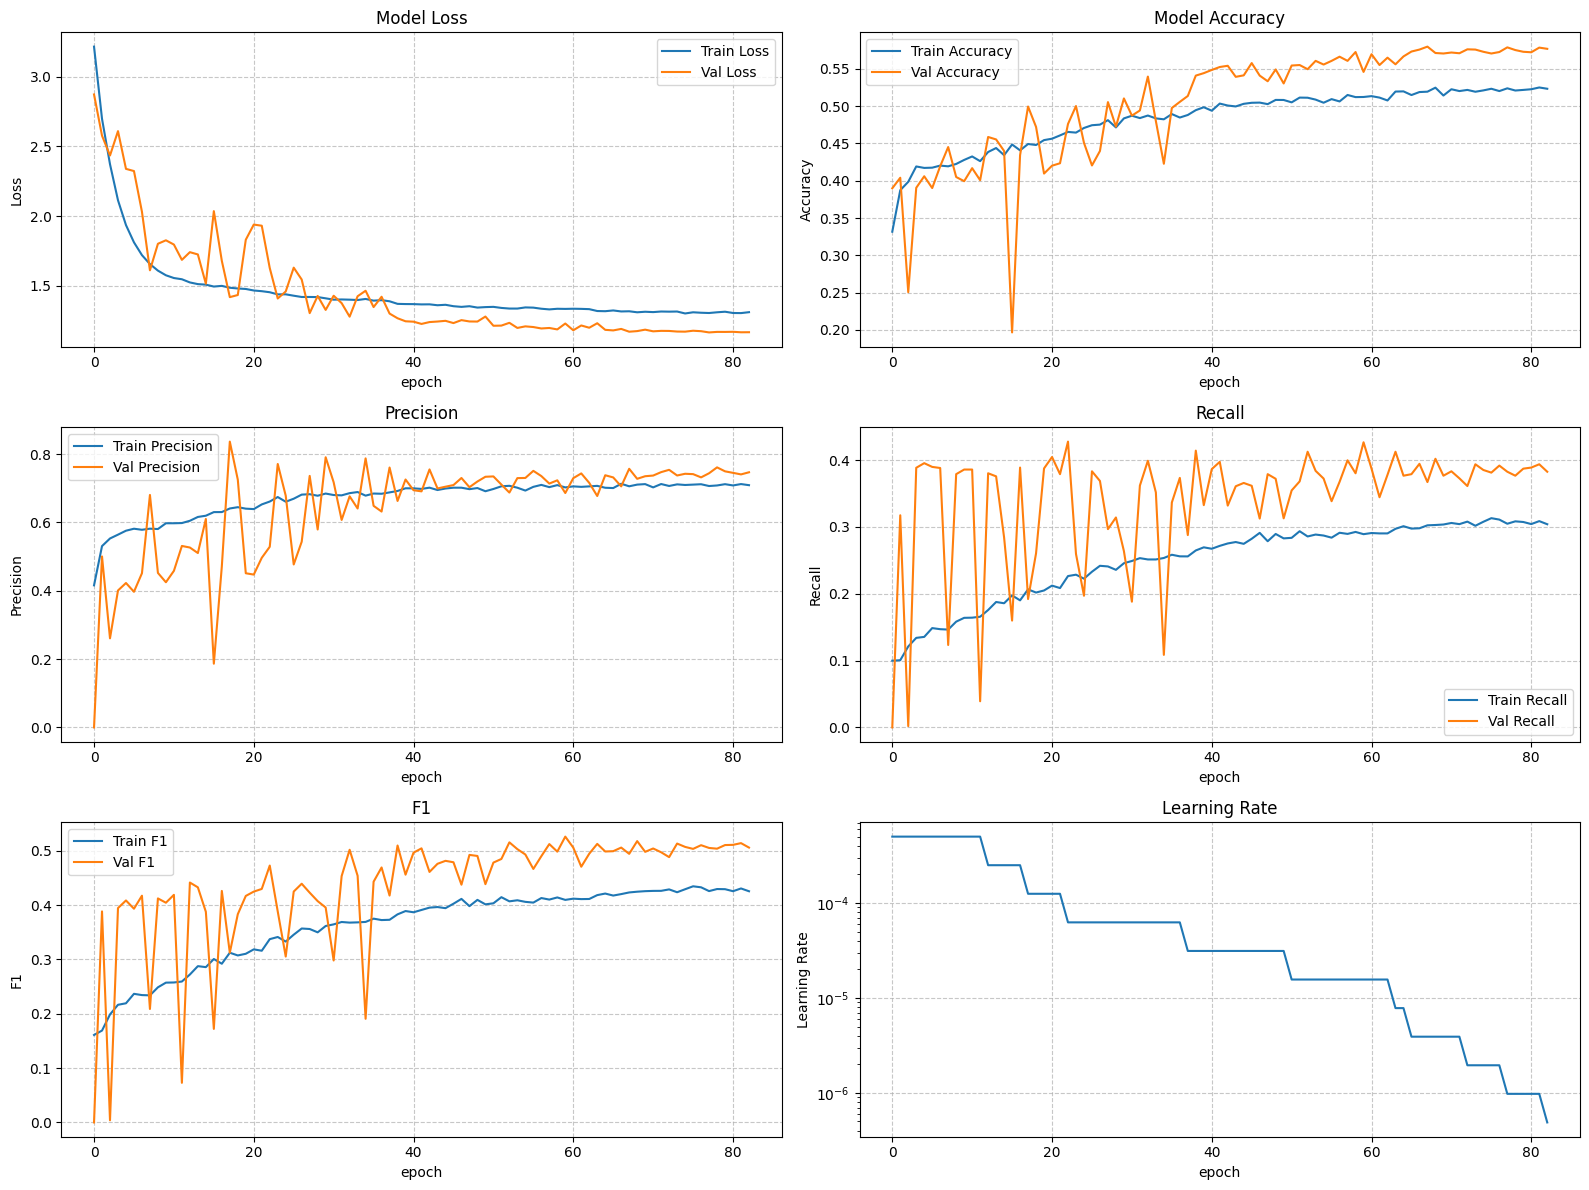

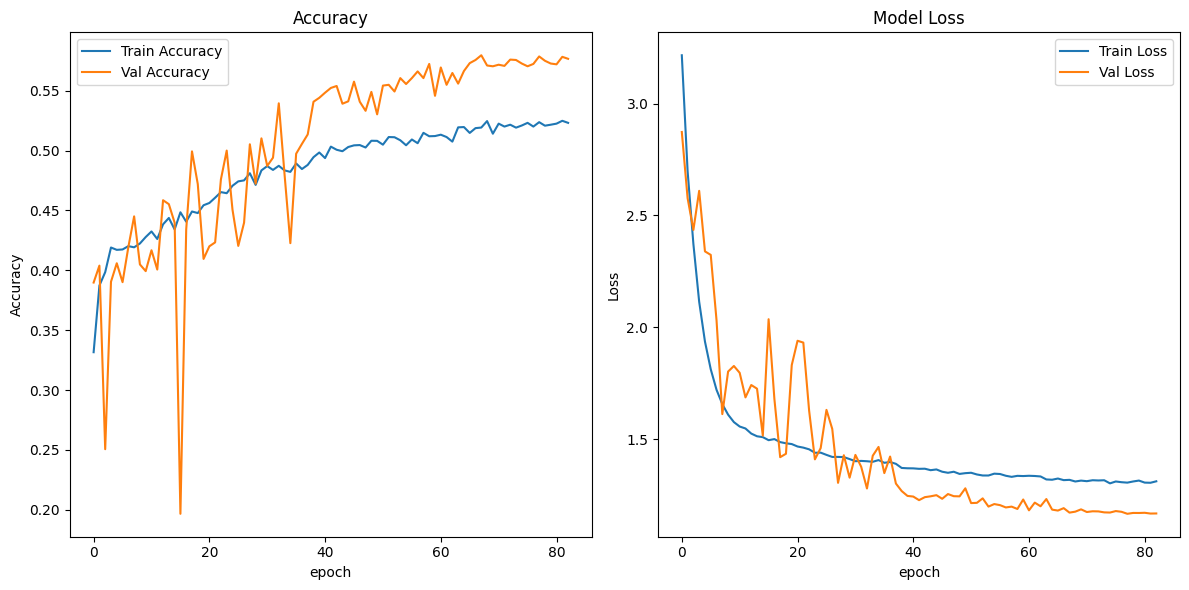

In [2]:
import os
import sys
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input, LeakyReLU
# 新增的导入
from tensorflow.keras.layers import LayerNormalization, MultiHeadAttention, Add, Reshape, GlobalAveragePooling1D, Layer
# 可选：也可从 tf.keras.models 导入 Model，但此处直接用 tf.keras.Model 即可
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
import matplotlib.pyplot as plt
# 设置matplotlib中文字体支持
import matplotlib.pyplot as plt
# 新增：注册自定义层为可序列化
from tensorflow.keras.utils import register_keras_serializable

# 添加错误处理和日志记录
print("启动FER2013情绪识别模型训练...")
print(f"Python版本: {sys.version}")
print(f"TensorFlow版本: {tf.__version__}")

# 设置随机种子以保证结果可复现
tf.random.set_seed(42)
np.random.seed(42)

# 数据集路径（分别指定训练集与验证集）
train_dir = r"../RAF-DB/train"
val_dir = r"../RAF-DB/test"

# 检查数据集路径是否存在
if not os.path.isdir(train_dir):
    print(f"错误: 训练集路径 '{train_dir}' 不存在。请检查路径是否正确。")
    sys.exit(1)
if not os.path.isdir(val_dir):
    print(f"错误: 验证集路径 '{val_dir}' 不存在。请检查路径是否正确。")
    sys.exit(1)

print(f"使用训练集路径: {train_dir}")
print(f"使用验证集路径: {val_dir}")

# 图像参数 - 调整为更适合人脸处理的尺寸
# 处理后的人脸图像尺寸
processed_img_width, processed_img_height = 96, 96  # 增大尺寸以获取更多人脸细节

# 原始输入图像尺寸（用于数据加载）
img_width, img_height = processed_img_width, processed_img_height

batch_size = 32   # 减小batch_size以提高人脸预处理器性能
epochs = 100       # 减少训练轮数以快速验证

# 设置人脸预处理参数 - 优化性能
face_detection_params = {
    'confidence_threshold': 0.9,  # 适度降低置信度阈值以提高检测速度
    'padding': 10,  # 适当减少填充以减少处理时间
    'grayscale': True  # 根据模型需求设置是否转换为灰度图
}

try:
        # 先创建基本的数据生成器对象
        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=20,
            width_shift_range=0.15,
            height_shift_range=0.15,
            shear_range=0.2,
            zoom_range=0.2,
            horizontal_flip=True,
            vertical_flip=False,
            brightness_range=[0.8, 1.2],
            channel_shift_range=0.1
        )
        
        validation_datagen = ImageDataGenerator(
            rescale=1./255
        )
        
        train_generator = train_datagen.flow_from_directory(
            train_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            color_mode='grayscale',
            class_mode='categorical',
            shuffle=True
        )

        validation_generator = validation_datagen.flow_from_directory(
            val_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            color_mode='grayscale',
            class_mode='categorical',
            shuffle=False
        )
        print("已切换到标准数据生成器。")
except Exception as e2:
        print(f"加载数据时出错: {str(e2)}")
        print("请确保数据集文件夹结构正确，并且包含正确的子文件夹。")
        print("建议运行install_dependencies.py来安装所有必要的依赖项。")
        sys.exit(1)

# 获取类别标签
class_labels = list(train_generator.class_indices.keys())
print("情绪类别:", class_labels)

# 构建注意力机制模型（ViT风格：Conv打补丁 + Transformer Encoder），保留L2/Dropout/LeakyReLU等超参数
patch_size = 8                       # 96x96 -> 12x12 = 144个patch
embed_dim = 128                      # 嵌入维度（可按需调大/调小）
num_heads = 4                        # 多头注意力头数
transformer_layers = 4               # Transformer编码层数
mlp_units = 256                      # 前馈网络维度
dropout_rate = 0.5                   # 保持与原FC部分相同的dropout强度
l2_reg = 0.001                       # 保持原有L2

inputs = Input(shape=(img_width, img_height, 1), name='input')

# Patch Embedding：用卷积直接打补丁并投影到embed_dim
x = Conv2D(
    filters=embed_dim,
    kernel_size=patch_size,
    strides=patch_size,
    padding='valid',
    name='patch_embedding'
)(inputs)  # (None, 12, 12, embed_dim)

h = img_height // patch_size
w = img_width // patch_size
num_patches = h * w

# 展平成序列 (batch, num_patches, embed_dim)
x = Reshape((num_patches, embed_dim), name='patch_reshape')(x)

# 可学习位置编码
@register_keras_serializable(package="FER")
class PositionalEmbedding(Layer):
    def __init__(self, num_patches, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.embed_dim = embed_dim
    def build(self, input_shape):
        self.pos_emb = self.add_weight(
            name='pos_emb',
            shape=(1, self.num_patches, self.embed_dim),
            initializer='zeros',
            trainable=True
        )
    def call(self, inputs):
        return inputs + self.pos_emb
    # 新增：序列化所需的配置
    def get_config(self):
        config = super().get_config()
        config.update({
            "num_patches": self.num_patches,
            "embed_dim": self.embed_dim,
        })
        return config
    @classmethod
    def from_config(cls, config):
        return cls(**config)

x = PositionalEmbedding(num_patches, embed_dim, name='positional_embedding')(x)

# 定义一个Transformer Encoder Block
def transformer_block(x, i):
    # LN + MHA + 残差
    attn_in = LayerNormalization(epsilon=1e-6, name=f'transformer_{i}_ln1')(x)
    attn_out = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
        dropout=dropout_rate,
        name=f'transformer_{i}_mha'
    )(attn_in, attn_in)
    x = Add(name=f'transformer_{i}_add1')([x, attn_out])

    # LN + MLP(含L2与LeakyReLU) + 残差
    ffn_in = LayerNormalization(epsilon=1e-6, name=f'transformer_{i}_ln2')(x)
    y = Dense(mlp_units, kernel_regularizer=l2(l2_reg), name=f'transformer_{i}_ffn_dense1')(ffn_in)
    y = LeakyReLU(alpha=0.1, name=f'transformer_{i}_ffn_act')(y)
    y = Dropout(dropout_rate, name=f'transformer_{i}_ffn_dropout')(y)
    y = Dense(embed_dim, kernel_regularizer=l2(l2_reg), name=f'transformer_{i}_ffn_dense2')(y)
    x = Add(name=f'transformer_{i}_add2')([x, y])
    return x

for i in range(transformer_layers):
    x = transformer_block(x, i)

# 分类头：LN + GAP + FC(保持原有正则与激活/BN/Dropout风格)
x = LayerNormalization(epsilon=1e-6, name='pre_head_ln')(x)
x = GlobalAveragePooling1D(name='sequence_pool')(x)

x = Dense(256, kernel_regularizer=l2(l2_reg), name='fc1')(x)
x = BatchNormalization(name='fc1_bn')(x)
x = LeakyReLU(alpha=0.1, name='fc1_act')(x)
x = Dropout(dropout_rate, name='fc1_drop')(x)

outputs = Dense(len(class_labels), activation='softmax', name='predictions')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs, name='FER_Transformer')

# 编译模型
# 针对更大模型调整学习率和优化器参数
initial_learning_rate = 0.0005  # 降低学习率以适应更大的模型
optimizer = Adam(
    learning_rate=initial_learning_rate,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07,
    amsgrad=False
)

# 使用兼容的指标格式
from tensorflow.keras.metrics import Precision, Recall

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=[
        'accuracy', 
        Precision(name='precision'), 
        Recall(name='recall')
    ]  # 使用具体的指标对象
)

# 打印模型结构
model.summary()

# 创建保存目录
if not os.path.exists('models'):
    os.makedirs('models')

if not os.path.exists('logs'):
    os.makedirs('logs')

# 回调函数
early_stopping = EarlyStopping(
    monitor='val_accuracy',  # 监控验证准确率而不是损失
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1,
    cooldown=2
)

# 模型检查点 - 保存最佳模型
model_checkpoint = ModelCheckpoint(
    filepath=os.path.join('models', 'fer2013_best_model.h5'),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# CSV日志记录器
history_logger = CSVLogger(
    os.path.join('logs', 'training_history.csv'),
    append=False,
    separator=','
)

# 添加自定义回调以监控训练进度
class TrainingMonitor(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.start_time = time.time()
        print(f"开始训练... 预计训练轮数: {epochs}")
        print(f"使用优化器: {model.optimizer.__class__.__name__}")
        print(f"初始学习率: {initial_learning_rate}")
        print(f"Batch大小: {batch_size}")
        
    def on_epoch_end(self, epoch, logs=None):
        elapsed_time = time.time() - self.start_time
        remaining_time = (epochs - epoch - 1) * (elapsed_time / (epoch + 1)) / 60  # 预估剩余时间(分钟)
        
        # 打印更多指标
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"训练: 损失={logs['loss']:.4f}, 准确率={logs['accuracy']:.4f}")
        if 'precision' in logs and 'recall' in logs:
            print(f"训练: 精确率={logs['precision']:.4f}, 召回率={logs['recall']:.4f}")
        
        print(f"验证: 损失={logs['val_loss']:.4f}, 准确率={logs['val_accuracy']:.4f}")
        if 'val_precision' in logs and 'val_recall' in logs:
            print(f"验证: 精确率={logs['val_precision']:.4f}, 召回率={logs['val_recall']:.4f}")
        
        # 计算和打印F1分数
        if 'val_precision' in logs and 'val_recall' in logs and logs['val_precision'] + logs['val_recall'] > 0:
            val_f1 = 2 * (logs['val_precision'] * logs['val_recall']) / (logs['val_precision'] + logs['val_recall'])
            print(f"验证: F1分数={val_f1:.4f}")
        
        print(f"已用时: {elapsed_time/60:.2f}分钟, 预计剩余: {remaining_time:.2f}分钟")
        print(f"当前学习率: {tf.keras.backend.get_value(model.optimizer.learning_rate):.6f}")
        print("=" * 50)

# 训练模型
try:
    print("\n开始模型训练...")
    print(f"训练样本数: {train_generator.samples}")
    print(f"验证样本数: {validation_generator.samples}")
    print(f"类别数: {len(class_labels)}")
    
    # 使用所有回调函数
    callbacks = [
        early_stopping,
        reduce_lr,
        model_checkpoint,
        history_logger,
        TrainingMonitor()
    ]
    
    history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // batch_size,
        epochs=epochs,
        validation_data=validation_generator,
        validation_steps=validation_generator.samples // batch_size,
        callbacks=callbacks,
        verbose=1
    )
except Exception as e:
    print(f"训练过程中出错: {str(e)}")
    print("如果是内存不足问题，建议减小batch_size值。")
    sys.exit(1)

# 保存最终模型
model_dir = 'models'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

model_path = os.path.join(model_dir, 'fer2013_final_model.h5')
model.save(model_path)
print(f"最终模型已保存为 '{model_path}'")
print(f"最佳模型已保存为 'models/fer2013_best_model.h5'")
print(f"训练日志已保存为 'logs/training_history.csv'")

# 加载最佳模型进行评估
try:
    print("\n评估最佳模型性能...")
    # 加载模型时提供自定义对象
    best_model = tf.keras.models.load_model(
        os.path.join('models', 'fer2013_best_model.h5'),
        custom_objects={
            'Precision': Precision,
            'Recall': Recall,
            # 新增：注册映射（即使已注册为可序列化，也可保底传入）
            'PositionalEmbedding': PositionalEmbedding
        }
    )
    
    # 评估模型 - 不直接解构返回值
    eval_results = best_model.evaluate(validation_generator, verbose=0)
    
    # 提取评估指标
    loss = eval_results[0]
    accuracy = eval_results[1]
    
    # 检查是否有额外的指标
    precision = recall = f1_score = 0
    if len(eval_results) > 2:
        precision = eval_results[2]
        if len(eval_results) > 3:
            recall = eval_results[3]
        if precision + recall > 0:
            f1_score = 2 * (precision * recall) / (precision + recall)
    
    print(f"验证集损失: {loss:.4f}")
    print(f"验证集准确率: {accuracy:.4f}")
    if len(eval_results) > 2:
        print(f"验证集精确率: {precision:.4f}")
    if len(eval_results) > 3:
        print(f"验证集召回率: {recall:.4f}")
        print(f"验证集F1分数: {f1_score:.4f}")
    
    # 保存评估结果到文件
    with open(os.path.join('logs', 'evaluation_results.txt'), 'w') as f:
        f.write(f"模型评估结果\n")
        f.write(f"验证集损失: {loss:.4f}\n")
        f.write(f"验证集准确率: {accuracy:.4f}\n")
        if len(eval_results) > 2:
            f.write(f"验证集精确率: {precision:.4f}\n")
        if len(eval_results) > 3:
            f.write(f"验证集召回率: {recall:.4f}\n")
            f.write(f"验证集F1分数: {f1_score:.4f}\n")
        f.write(f"\n训练参数:\n")
        f.write(f"初始学习率: {initial_learning_rate}\n")
        f.write(f"Batch大小: {batch_size}\n")
        f.write(f"训练轮数: {epochs}\n")
        f.write(f"最终学习率: {tf.keras.backend.get_value(model.optimizer.learning_rate):.6f}\n")
        f.write(f"\n类别标签: {class_labels}\n")
        
except Exception as e:
    print(f"评估模型时出错: {str(e)}")
    print("使用当前模型进行评估...")
    try:
        # 不直接解构返回值
        eval_results = model.evaluate(validation_generator, verbose=0)
        loss = eval_results[0]
        accuracy = eval_results[1]
        print(f"验证集损失: {loss:.4f}")
        print(f"验证集准确率: {accuracy:.4f}")
    except Exception as e2:
        print(f"再次评估失败: {str(e2)}")

# 绘制训练历史
try:
    print("\n绘制训练历史图表...")
    
    # 创建图表目录
    plots_dir = 'plots'
    if not os.path.exists(plots_dir):
        os.makedirs(plots_dir)
    
    # 绘制完整的训练历史图表
    plt.figure(figsize=(16, 12))
    
    # 1. 绘制损失曲线
    plt.subplot(3, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 2. 绘制准确率曲线
    plt.subplot(3, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 3. 如果有精确率和召回率指标，也绘制出来
    if 'precision' in history.history and 'val_precision' in history.history:
        plt.subplot(3, 2, 3)
        plt.plot(history.history['precision'], label='Train Precision')
        plt.plot(history.history['val_precision'], label='Val Precision')
        plt.title('Precision')
        plt.xlabel('epoch')
        plt.ylabel('Precision')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    if 'recall' in history.history and 'val_recall' in history.history:
        plt.subplot(3, 2, 4)
        plt.plot(history.history['recall'], label='Train Recall')
        plt.plot(history.history['val_recall'], label='Val Recall')
        plt.title('Recall')
        plt.xlabel('epoch')
        plt.ylabel('Recall')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        
        # 计算F1分数
        train_f1_scores = []
        val_f1_scores = []
        for p, r, vp, vr in zip(history.history['precision'], history.history['recall'],
                              history.history['val_precision'], history.history['val_recall']):
            train_f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0
            val_f1 = 2 * (vp * vr) / (vp + vr) if (vp + vr) > 0 else 0
            train_f1_scores.append(train_f1)
            val_f1_scores.append(val_f1)
        
        plt.subplot(3, 2, 5)
        plt.plot(train_f1_scores, label='Train F1')
        plt.plot(val_f1_scores, label='Val F1')
        plt.title('F1')
        plt.xlabel('epoch')
        plt.ylabel('F1')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    # 6. 绘制学习率变化
    plt.subplot(3, 2, 6)
    # 获取学习率历史
    lr_history = [initial_learning_rate]
    current_lr = initial_learning_rate
    for i in range(1, len(history.history['loss'])):
        # 模拟ReduceLROnPlateau的行为
        if i > 0 and 'val_accuracy' in history.history:
            # 检查是否在最近的patience轮中没有改善
            if i >= reduce_lr.patience:
                recent_val_acc = history.history['val_accuracy'][i-reduce_lr.patience:i]
                if len(recent_val_acc) > 0 and max(recent_val_acc) == recent_val_acc[0]:
                    current_lr *= reduce_lr.factor
                    current_lr = max(current_lr, reduce_lr.min_lr)
        lr_history.append(current_lr)
    
    plt.plot(lr_history)
    plt.title('Learning Rate')
    plt.xlabel('epoch')
    plt.ylabel('Learning Rate')
    plt.yscale('log')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    
    # 保存完整的训练历史图表
    plt.savefig(os.path.join(plots_dir, 'training_history_full.png'), dpi=300, bbox_inches='tight')
    print("完整训练历史图表已保存。")
    
    # 保存单独的简化图表，便于快速查看
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Accuracy')
    plt.xlabel('epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, 'training_history_simple.png'))
    print("简化训练历史图表已保存。")
    
    # 在非交互式环境中不显示图表
    if os.environ.get('DISPLAY') or sys.platform == 'win32':
        plt.show()
    else:
        print("在无头环境中运行，跳过显示图表。")
    
except Exception as e:
    print(f"绘制图表时出错: {str(e)}")

print("\n训练完成!")
print("\n使用说明:")
print("1. 训练好的模型保存在 'models/' 文件夹中:")
print("   - 'fer2013_best_model.h5': 验证集性能最佳的模型")
print("   - 'fer2013_final_model.h5': 最终训练轮次的模型")
print("2. 训练相关文件:")
print("   - 'logs/training_history.csv': 详细的训练日志")
print("   - 'logs/evaluation_results.txt': 模型评估结果")
print("   - 'plots/training_history_full.png': 完整的训练历史图表")
print("   - 'plots/training_history_simple.png': 简化的训练历史图表")
print("3. 主要优化点:")
print("   - 改进的CNN架构，包含更多卷积层和特征提取能力")
print("   - 使用LeakyReLU激活函数和L2正则化减少过拟合")
print("   - 增强的数据增强策略提高模型泛化能力")
print("   - 自适应学习率调整和早停机制优化训练过程")
print("   - 多指标评估（准确率、精确率、召回率、F1分数）")
print("4. 可调整参数:")
print("   - 'initial_learning_rate': 初始学习率")
print("   - 'batch_size': 批次大小")
print("   - 'epochs': 训练轮数")
print("   - 数据增强参数在'train_datagen'中设置")
print("5. 如有任何问题，请先运行 fix_deps.bat 来修复依赖项")
print("6. 建议在训练后查看完整的评估结果和训练历史图表")
print("7. 人脸预处理功能：")
print("   - 模型现在集成了MTCNN人脸检测和对齐功能")
print("   - 首次运行时会下载MTCNN权重文件，这可能需要一些时间")
print("   - 如果人脸检测失败，会自动切换到标准数据处理流程")
print("   - 人脸预处理模块位于face_preprocessor.py中，可以单独使用")
print("8. 可调整的人脸预处理参数：")
print("   - 在face_preprocessor.py中可以调整padding（人脸框填充像素）")
print("   - 可以修改confidence_threshold（人脸检测置信度阈值）")
print("   - 数据增强参数在create_face_preprocessing_generator调用中设置")
print("9. 模型尺寸调整：")
print("   - 输入图像尺寸已从48x48调整为96x96，以获取更多人脸细节")
print("   - CNN模型结构已优化，增加了卷积层和全连接层以适应更大的输入尺寸")
print("   - 学习率已降低以适应更大的模型结构")

2025-10-08 12:10:09.656046: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-08 12:10:11.555799: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-08 12:10:16.159675: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-08 12:10:20.282173: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; 

启动FER2013情绪识别模型训练...
Python版本: 3.8.18 (default, Sep 11 2023, 13:40:15) 
[GCC 11.2.0]
TensorFlow版本: 2.10.1
使用训练集路径: ../RAF-DB/train
使用验证集路径: ../RAF-DB/test
Found 12271 images belonging to 7 classes.
Found 3068 images belonging to 7 classes.
已切换到标准数据生成器。
情绪类别: ['anger', 'disgust', 'fear', 'happy', 'normal', 'sad', 'surprised']


2025-10-08 12:10:35.903162: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-08 12:10:38.710984: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:42] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
2025-10-08 12:10:38.711043: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1616] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3956 MB memory:  -> device: 0, name: B1.gpu.small, pci bus id: 0000:c0:00.0, compute capability: 8.6


16705208/16705208 [==============================] - 11s 1us/step
Model: "FER_EfficientNetB0"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input (InputLayer)             [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 rescaling (Rescaling)          (None, 224, 224, 3)  0           ['input[0][0]']                  
                                                                                                  
 normalization (Normalization)  (None, 224, 224, 3)  7           ['rescaling[0][0]']              
                                                                                                  
 rescaling_1 (R

2025-10-08 12:11:04.355711: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8101
2025-10-08 12:11:10.829141: I tensorflow/stream_executor/cuda/cuda_blas.cc:1614] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


383/383 [==============================] - ETA: 0s - loss: 2.7638 - accuracy: 0.3181 - precision: 0.5344 - recall: 0.1309
Epoch 1: val_loss improved from inf to 2.11850, saving model to models/fer2013_best.weights.h5

Epoch 1/100
训练: 损失=2.7638, 准确率=0.3181
训练: 精确率=0.5344, 召回率=0.1309
验证: 损失=2.1185, 准确率=0.5312
验证: 精确率=0.7381, 召回率=0.2605
验证: F1分数=0.3851
已用时: 2.79分钟, 预计剩余: 276.32分钟
当前学习率: 0.000100
383/383 [==============================] - 167s 399ms/step - loss: 2.7638 - accuracy: 0.3181 - precision: 0.5344 - recall: 0.1309 - val_loss: 2.1185 - val_accuracy: 0.5312 - val_precision: 0.7381 - val_recall: 0.2605 - lr: 1.0000e-04
Epoch 2/100
383/383 [==============================] - ETA: 0s - loss: 2.4099 - accuracy: 0.4380 - precision: 0.6904 - recall: 0.1693
Epoch 2: val_loss improved from 2.11850 to 2.00101, saving model to models/fer2013_best.weights.h5

Epoch 2/100
训练: 损失=2.4099, 准确率=0.4380
训练: 精确率=0.6904, 召回率=0.1693
验证: 损失=2.0010, 准确率=0.5980
验证: 精确率=0.8393, 召回率=0.2852
验证: F1分数=0.4257
已用

INFO:tensorflow:Assets written to: models/fer2013_saved_model/assets


INFO:tensorflow:Assets written to: models/fer2013_saved_model/assets


推理模型已以 SavedModel 形式保存到 'models/fer2013_saved_model'

评估最佳模型性能...
验证集损失: 0.9883
验证集准确率: 0.8181
验证集精确率: 0.8774
验证集召回率: 0.7533
验证集F1分数: 0.8106

绘制训练历史图表...
完整训练历史图表已保存。
简化训练历史图表已保存。
在无头环境中运行，跳过显示图表。

训练完成!


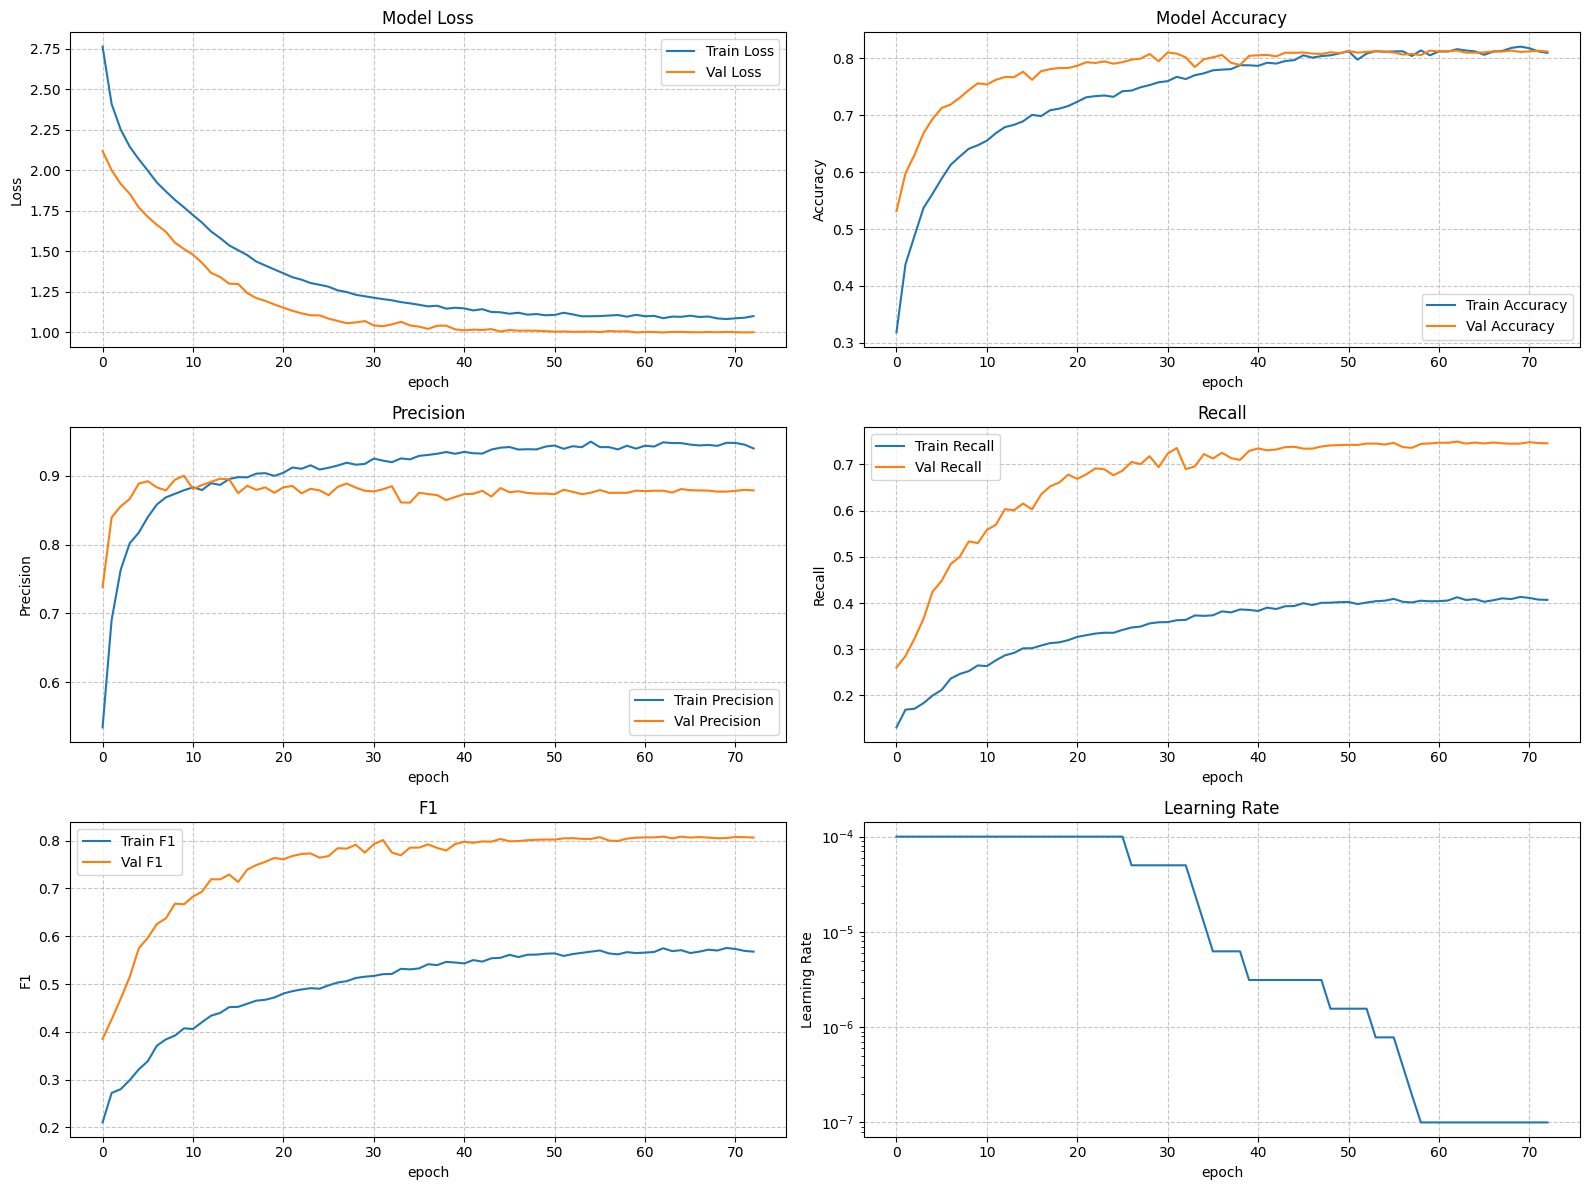

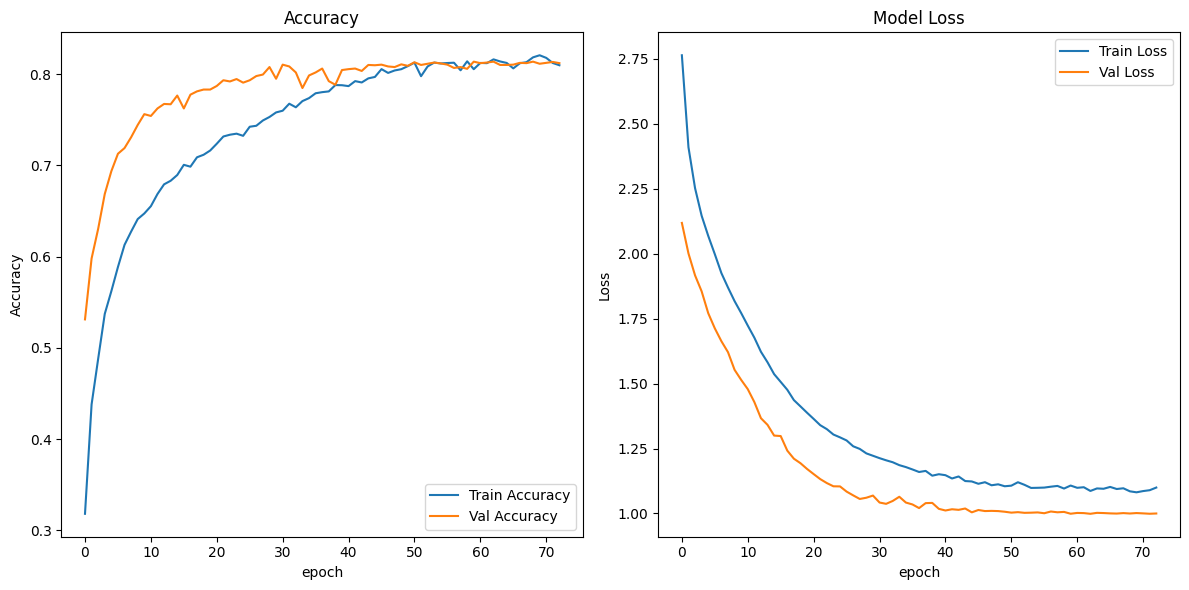

In [1]:
import os
import sys
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input, LeakyReLU
# 新增的导入
from tensorflow.keras.layers import LayerNormalization, MultiHeadAttention, Add, Reshape, GlobalAveragePooling1D, Layer
# 新增（迁移学习与2D池化/损失）
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.layers import GlobalAveragePooling2D
# 可选：也可从 tf.keras.models 导入 Model，但此处直接用 tf.keras.Model 即可
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
import matplotlib.pyplot as plt
# 设置matplotlib中文字体支持
import matplotlib.pyplot as plt
# 新增：注册自定义层为可序列化
from tensorflow.keras.utils import register_keras_serializable

# 添加错误处理和日志记录
print("启动FER2013情绪识别模型训练...")
print(f"Python版本: {sys.version}")
print(f"TensorFlow版本: {tf.__version__}")

# 设置随机种子以保证结果可复现
tf.random.set_seed(42)
np.random.seed(42)

# ========== 新增：Random Erasing + 预处理函数 ==========
def _random_erasing_numpy(img, p=0.5, s_l=0.02, s_h=0.2, r1=0.3):
    # img: HWC, [0,255]
    if np.random.rand() > p:
        return img
    H, W, C = img.shape
    S = H * W
    for _ in range(10):
        target = np.random.uniform(s_l, s_h) * S
        ratio = np.random.uniform(r1, 1 / r1)
        h = int(np.sqrt(target * ratio))
        w = int(np.sqrt(target / ratio))
        if h < H and w < W:
            y1 = np.random.randint(0, H - h + 1)
            x1 = np.random.randint(0, W - w + 1)
            # 用均值或随机值擦除
            erase_val = np.random.uniform(0, 255, (h, w, C)).astype(img.dtype)
            img[y1:y1 + h, x1:x1 + w, :] = erase_val
            break
    return img

def effnet_preprocess_with_erasing(x):
    # ImageDataGenerator 传入的是 numpy 数组
    x = x.astype(np.float32)
    x = _random_erasing_numpy(x, p=0.5)
    return tf.keras.applications.efficientnet.preprocess_input(x)
# ========== 新增结束 ==========

# 数据集路径（分别指定训练集与验证集）
train_dir = r"../RAF-DB/train"
val_dir = r"../RAF-DB/test"

# 检查数据集路径是否存在
if not os.path.isdir(train_dir):
    print(f"错误: 训练集路径 '{train_dir}' 不存在。请检查路径是否正确。")
    sys.exit(1)
if not os.path.isdir(val_dir):
    print(f"错误: 验证集路径 '{val_dir}' 不存在。请检查路径是否正确。")
    sys.exit(1)

print(f"使用训练集路径: {train_dir}")
print(f"使用验证集路径: {val_dir}")

# 图像参数 - 调整为更适合人脸处理的尺寸
# 处理后的人脸图像尺寸
processed_img_width, processed_img_height = 224, 224  # 迁移学习常用输入

# 原始输入图像尺寸（用于数据加载）
img_width, img_height = processed_img_width, processed_img_height

batch_size = 32   # 减小batch_size以提高人脸预处理器性能
epochs = 100       # 减少训练轮数以快速验证

# 设置人脸预处理参数 - 优化性能
face_detection_params = {
    'confidence_threshold': 0.9,  # 适度降低置信度阈值以提高检测速度
    'padding': 10,  # 适当减少填充以减少处理时间
    'grayscale': True  # 根据模型需求设置是否转换为灰度图
}

try:
        # 训练增强：启用 Random Erasing + 常规几何增强
        train_datagen = ImageDataGenerator(
            preprocessing_function=effnet_preprocess_with_erasing,
            rotation_range=20,
            width_shift_range=0.15,
            height_shift_range=0.15,
            shear_range=0.2,
            zoom_range=0.2,
            horizontal_flip=True,
            vertical_flip=False,
            brightness_range=[0.8, 1.2]
        )
        
        validation_datagen = ImageDataGenerator(
            preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
        )
        
        train_generator = train_datagen.flow_from_directory(
            train_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            color_mode='rgb',          # 使用RGB以适配ImageNet预训练
            class_mode='categorical',
            shuffle=True
        )

        validation_generator = validation_datagen.flow_from_directory(
            val_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            color_mode='rgb',          # 使用RGB
            class_mode='categorical',
            shuffle=False
        )
        print("已切换到标准数据生成器。")
except Exception as e2:
        print(f"加载数据时出错: {str(e2)}")
        print("请确保数据集文件夹结构正确，并且包含正确的子文件夹。")
        print("建议运行install_dependencies.py来安装所有必要的依赖项。")
        sys.exit(1)

# 获取类别标签
class_labels = list(train_generator.class_indices.keys())
print("情绪类别:", class_labels)

# 使用预训练EfficientNetB0 + 顶部分类头（含SE注意力的主干）
l2_reg = 0.0015            # 加强 L2
dropout_rate = 0.5         # 加强 Dropout

inputs = Input(shape=(img_width, img_height, 3), name='input')
base_model = EfficientNetB0(include_top=False, input_tensor=inputs, weights='imagenet')

# 冻结约70%的底层特征，微调高层
fine_tune_at = int(len(base_model.layers) * 0.7)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

x = base_model.outputs[0]
x = GlobalAveragePooling2D(name='gap')(x)
x = Dropout(dropout_rate, name='top_drop1')(x)
x = Dense(256, kernel_regularizer=l2(l2_reg), name='fc1')(x)
x = BatchNormalization(name='fc1_bn')(x)
x = LeakyReLU(alpha=0.1, name='fc1_act')(x)
x = Dropout(dropout_rate, name='top_drop2')(x)
outputs = Dense(len(class_labels), activation='softmax', name='predictions')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs, name='FER_EfficientNetB0')

# 编译模型
initial_learning_rate = 1e-4  # 迁移学习更稳妥
optimizer = Adam(
    learning_rate=initial_learning_rate,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07,
    amsgrad=False
)

loss_fn = CategoricalCrossentropy(label_smoothing=0.15)  # 提升标签平滑

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall')
    ]
)

# 打印模型结构
model.summary()

# 创建保存目录
if not os.path.exists('models'):
    os.makedirs('models')

if not os.path.exists('logs'):
    os.makedirs('logs')

# 回调函数
early_stopping = EarlyStopping(
    monitor='val_loss',  # 改为验证损失，更稳定
    patience=10,         # 略收紧，避免过拟合拉长
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',  # 改为验证损失
    factor=0.5,
    patience=3,          # 更快降低学习率以摆脱平台期
    min_lr=1e-7,
    verbose=1,
    cooldown=1
)

# 模型检查点 - 保存最佳模型（以验证损失为准）
model_checkpoint = ModelCheckpoint(
    filepath=os.path.join('models', 'fer2013_best.weights.h5'),  # 仅保存权重
    monitor='val_loss',        # 改为验证损失
    save_best_only=True,
    save_weights_only=True,    # 关键：只保存权重，避免序列化模型配置
    mode='min',
    verbose=1
)

# CSV日志记录器
history_logger = CSVLogger(
    os.path.join('logs', 'training_history.csv'),
    append=False,
    separator=','
)

# ========== 替换并增强：MixUp / CutMix 训练生成器 ==========
def mixup_generator(generator, alpha=0.2):
    while True:
        x, y = next(generator)
        b = x.shape[0]
        if b <= 1:
            yield x, y; continue
        lam = np.random.beta(alpha, alpha)
        idx = np.random.permutation(b)
        x = lam * x + (1.0 - lam) * x[idx]
        y = lam * y + (1.0 - lam) * y[idx]
        yield x, y

def _rand_bbox(W, H, lam):
    r = np.sqrt(1. - lam)
    cut_w, cut_h = int(W * r), int(H * r)
    cx, cy = np.random.randint(W), np.random.randint(H)
    x1 = np.clip(cx - cut_w // 2, 0, W)
    y1 = np.clip(cy - cut_h // 2, 0, H)
    x2 = np.clip(cx + cut_w // 2, 0, W)
    y2 = np.clip(cy + cut_h // 2, 0, H)
    return x1, y1, x2, y2

def cutmix_generator(generator, alpha=1.0):
    while True:
        x, y = next(generator)
        b, H, W, C = x.shape
        if b <= 1:
            yield x, y; continue
        lam = np.random.beta(alpha, alpha)
        idx = np.random.permutation(b)
        x1, y1, x2, y2 = _rand_bbox(W, H, lam)
        x_mix = x.copy()
        x_mix[:, y1:y2, x1:x2, :] = x[idx, y1:y2, x1:x2, :]
        # 按面积修正 lambda
        lam_adj = 1. - ((x2 - x1) * (y2 - y1)) / (W * H)
        y_mix = lam_adj * y + (1. - lam_adj) * y[idx]
        yield x_mix, y_mix

def mixup_or_cutmix_generator(generator, mixup_alpha=0.2, cutmix_alpha=1.0, p_mixup=0.5):
    while True:
        if np.random.rand() < p_mixup:
            yield from mixup_generator(generator, alpha=mixup_alpha)
        else:
            yield from cutmix_generator(generator, alpha=cutmix_alpha)

# 选择混合策略：'none' | 'mixup' | 'cutmix' | 'both'
mix_strategy = 'both'
if mix_strategy == 'mixup':
    train_generator_eff = mixup_generator(train_generator, alpha=0.2)
elif mix_strategy == 'cutmix':
    train_generator_eff = cutmix_generator(train_generator, alpha=1.0)
elif mix_strategy == 'both':
    train_generator_eff = mixup_or_cutmix_generator(train_generator, mixup_alpha=0.2, cutmix_alpha=1.0, p_mixup=0.5)
else:
    train_generator_eff = train_generator
# ========== 结束 ==========

# 新增：MixUp 数据增强（参考 FAF_CNN.py 的实现）
def mixup_generator(generator, alpha=0.2):
    """对任意 keras generator 进行 MixUp；每次仅使用一个 batch 内的随机配对。"""
    while True:
        x, y = next(generator)       # x:(B,H,W,C) y:(B,K)
        b = x.shape[0]
        if b <= 1:
            yield x, y
            continue
        lam = np.random.beta(alpha, alpha, size=b).astype(np.float32)
        idx = np.random.permutation(b)
        lam_x = lam.reshape(-1, 1, 1, 1)
        lam_y = lam.reshape(-1, 1)
        x_mix = lam_x * x + (1.0 - lam_x) * x[idx]
        y_mix = lam_y * y + (1.0 - lam_y) * y[idx]
        yield x_mix, y_mix

use_mixup = True
mixup_alpha = 0.2
train_generator_eff = mixup_generator(train_generator, alpha=mixup_alpha) if use_mixup else train_generator

# 添加自定义回调以监控训练进度
class TrainingMonitor(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.start_time = time.time()
        print(f"开始训练... 预计训练轮数: {epochs}")
        print(f"使用优化器: {model.optimizer.__class__.__name__}")
        print(f"初始学习率: {initial_learning_rate}")
        print(f"Batch大小: {batch_size}")
        
    def on_epoch_end(self, epoch, logs=None):
        elapsed_time = time.time() - self.start_time
        remaining_time = (epochs - epoch - 1) * (elapsed_time / (epoch + 1)) / 60  # 预估剩余时间(分钟)
        
        # 打印更多指标
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"训练: 损失={logs['loss']:.4f}, 准确率={logs['accuracy']:.4f}")
        if 'precision' in logs and 'recall' in logs:
            print(f"训练: 精确率={logs['precision']:.4f}, 召回率={logs['recall']:.4f}")
        
        print(f"验证: 损失={logs['val_loss']:.4f}, 准确率={logs['val_accuracy']:.4f}")
        if 'val_precision' in logs and 'val_recall' in logs:
            print(f"验证: 精确率={logs['val_precision']:.4f}, 召回率={logs['val_recall']:.4f}")
        
        # 计算和打印F1分数
        if 'val_precision' in logs and 'val_recall' in logs and logs['val_precision'] + logs['val_recall'] > 0:
            val_f1 = 2 * (logs['val_precision'] * logs['val_recall']) / (logs['val_precision'] + logs['val_recall'])
            print(f"验证: F1分数={val_f1:.4f}")
        
        print(f"已用时: {elapsed_time/60:.2f}分钟, 预计剩余: {remaining_time:.2f}分钟")
        print(f"当前学习率: {tf.keras.backend.get_value(model.optimizer.learning_rate):.6f}")
        print("=" * 50)

# 训练模型
try:
    print("\n开始模型训练...")
    print(f"训练样本数: {train_generator.samples}")
    print(f"验证样本数: {validation_generator.samples}")
    print(f"类别数: {len(class_labels)}")
    
    # 新增：类别权重，缓解类不平衡
    counts = np.bincount(train_generator.classes)
    class_weights = {i: (counts.sum() / (len(counts) * c)) for i, c in enumerate(counts) if c > 0}
    print("类别样本数:", counts.tolist())
    print("类别权重:", class_weights)
    
    # 使用所有回调函数
    callbacks = [
        early_stopping,
        reduce_lr,
        model_checkpoint,
        history_logger,
        TrainingMonitor()
    ]
    
    history = model.fit(
        train_generator_eff,
        steps_per_epoch=train_generator.samples // batch_size,
        epochs=epochs,
        validation_data=validation_generator,
        validation_steps=validation_generator.samples // batch_size,
        callbacks=callbacks,
        class_weight=class_weights if (mix_strategy == 'none') else None,  # 使用混合增强时不叠加类别权重
        verbose=1
    )

    # 二阶段微调：解冻全部层并降低学习率
    for layer in base_model.layers:
        layer.trainable = True

    fine_tune_epochs = 20
    fine_tune_lr = initial_learning_rate * 0.1
    model.compile(
        optimizer=Adam(learning_rate=fine_tune_lr),
        loss=loss_fn,
        metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
    )
    print(f"\n开始全量微调: epochs={fine_tune_epochs}, 学习率={fine_tune_lr}")
    history_fine = model.fit(
        train_generator_eff,
        steps_per_epoch=train_generator.samples // batch_size,
        epochs=fine_tune_epochs,
        validation_data=validation_generator,
        validation_steps=validation_generator.samples // batch_size,
        callbacks=callbacks,
        class_weight=class_weights if (mix_strategy == 'none') else None,
        verbose=1
    )
except Exception as e:
    print(f"训练过程中出错: {str(e)}")
    print("如果是内存不足问题，建议减小batch_size值。")
    sys.exit(1)

# 保存最终模型
model_dir = 'models'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# 仅保存最终权重，避免 .keras 序列化报错
final_weights_path = os.path.join(model_dir, 'fer2013_final.weights.h5')
model.save_weights(final_weights_path)
print(f"最终权重已保存为 '{final_weights_path}'")
print(f"最佳权重已保存为 'models/fer2013_best.weights.h5'")
print(f"训练日志已保存为 'logs/training_history.csv'")

# 导出推理模型（不含优化器/训练配置）
inference_export_dir = os.path.join(model_dir, 'fer2013_saved_model')
try:
    model.export(inference_export_dir)  # Keras 3 的导出API
    print(f"推理模型已导出到 '{inference_export_dir}'")
except Exception as _:
    tf.saved_model.save(model, inference_export_dir)  # 向后兼容
    print(f"推理模型已以 SavedModel 形式保存到 '{inference_export_dir}'")

# 加载最佳模型进行评估
try:
    print("\n评估最佳模型性能...")
    # 直接把最佳权重加载回当前模型
    best_weights_path = os.path.join('models', 'fer2013_best.weights.h5')
    model.load_weights(best_weights_path)

    eval_results = model.evaluate(validation_generator, verbose=0)
    loss = eval_results[0]
    accuracy = eval_results[1]
    precision = eval_results[2] if len(eval_results) > 2 else 0.0
    recall = eval_results[3] if len(eval_results) > 3 else 0.0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    print(f"验证集损失: {loss:.4f}")
    print(f"验证集准确率: {accuracy:.4f}")
    if len(eval_results) > 2:
        print(f"验证集精确率: {precision:.4f}")
    if len(eval_results) > 3:
        print(f"验证集召回率: {recall:.4f}")
        print(f"验证集F1分数: {f1_score:.4f}")

    with open(os.path.join('logs', 'evaluation_results.txt'), 'w') as f:
        f.write(f"模型评估结果\n")
        f.write(f"验证集损失: {loss:.4f}\n")
        f.write(f"验证集准确率: {accuracy:.4f}\n")
        if len(eval_results) > 2:
            f.write(f"验证集精确率: {precision:.4f}\n")
        if len(eval_results) > 3:
            f.write(f"验证集召回率: {recall:.4f}\n")
            f.write(f"验证集F1分数: {f1_score:.4f}\n")
        f.write(f"\n训练参数:\n")
        f.write(f"初始学习率: {initial_learning_rate}\n")
        f.write(f"微调学习率: {fine_tune_lr}\n")
        f.write(f"Batch大小: {batch_size}\n")
        f.write(f"阶段1轮数: {epochs}, 阶段2轮数: {fine_tune_epochs}\n")
        f.write(f"\n类别标签: {class_labels}\n")

except Exception as e:
    print(f"评估模型时出错: {str(e)}")
    print("使用当前模型进行评估...")
    try:
        eval_results = model.evaluate(validation_generator, verbose=0)
        loss = eval_results[0]
        accuracy = eval_results[1]
        print(f"验证集损失: {loss:.4f}")
        print(f"验证集准确率: {accuracy:.4f}")
    except Exception as e2:
        print(f"再次评估失败: {str(e2)}")

# 绘制训练历史
try:
    print("\n绘制训练历史图表...")
    
    # 创建图表目录
    plots_dir = 'plots'
    if not os.path.exists(plots_dir):
        os.makedirs(plots_dir)
    
    # 绘制完整的训练历史图表
    plt.figure(figsize=(16, 12))
    
    # 1. 绘制损失曲线
    plt.subplot(3, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 2. 绘制准确率曲线
    plt.subplot(3, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 3. 如果有精确率和召回率指标，也绘制出来
    if 'precision' in history.history and 'val_precision' in history.history:
        plt.subplot(3, 2, 3)
        plt.plot(history.history['precision'], label='Train Precision')
        plt.plot(history.history['val_precision'], label='Val Precision')
        plt.title('Precision')
        plt.xlabel('epoch')
        plt.ylabel('Precision')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    if 'recall' in history.history and 'val_recall' in history.history:
        plt.subplot(3, 2, 4)
        plt.plot(history.history['recall'], label='Train Recall')
        plt.plot(history.history['val_recall'], label='Val Recall')
        plt.title('Recall')
        plt.xlabel('epoch')
        plt.ylabel('Recall')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        
        # 计算F1分数
        train_f1_scores = []
        val_f1_scores = []
        for p, r, vp, vr in zip(history.history['precision'], history.history['recall'],
                              history.history['val_precision'], history.history['val_recall']):
            train_f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0
            val_f1 = 2 * (vp * vr) / (vp + vr) if (vp + vr) > 0 else 0
            train_f1_scores.append(train_f1)
            val_f1_scores.append(val_f1)
        
        plt.subplot(3, 2, 5)
        plt.plot(train_f1_scores, label='Train F1')
        plt.plot(val_f1_scores, label='Val F1')
        plt.title('F1')
        plt.xlabel('epoch')
        plt.ylabel('F1')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    # 6. 绘制学习率变化
    plt.subplot(3, 2, 6)
    # 获取学习率历史
    lr_history = [initial_learning_rate]
    current_lr = initial_learning_rate
    for i in range(1, len(history.history['loss'])):
        # 模拟ReduceLROnPlateau的行为
        if i > 0 and 'val_accuracy' in history.history:
            # 检查是否在最近的patience轮中没有改善
            if i >= reduce_lr.patience:
                recent_val_acc = history.history['val_accuracy'][i-reduce_lr.patience:i]
                if len(recent_val_acc) > 0 and max(recent_val_acc) == recent_val_acc[0]:
                    current_lr *= reduce_lr.factor
                    current_lr = max(current_lr, reduce_lr.min_lr)
        lr_history.append(current_lr)
    
    plt.plot(lr_history)
    plt.title('Learning Rate')
    plt.xlabel('epoch')
    plt.ylabel('Learning Rate')
    plt.yscale('log')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    
    # 保存完整的训练历史图表
    plt.savefig(os.path.join(plots_dir, 'training_history_full.png'), dpi=300, bbox_inches='tight')
    print("完整训练历史图表已保存。")
    
    # 保存单独的简化图表，便于快速查看
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Accuracy')
    plt.xlabel('epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, 'training_history_simple.png'))
    print("简化训练历史图表已保存。")
    
    # 在非交互式环境中不显示图表
    if os.environ.get('DISPLAY') or sys.platform == 'win32':
        plt.show()
    else:
        print("在无头环境中运行，跳过显示图表。")
    
except Exception as e:
    print(f"绘制图表时出错: {str(e)}")

print("\n训练完成!")
